# CTR Prediction Platform — Exploratory Data Analysis

Phase 6. This notebook explores the processed dataset produced by the Phase 5
ETL pipeline: user behavior, campaign performance, device/browser/country
trends, hourly CTR patterns, and feature correlations, with the goal of
surfacing every signal the Phase 7 feature engineering and Phase 8 modeling
phases should exploit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
FIG_DIR = "figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_parquet("../data/processed/ctr_dataset_full.parquet")
print(df.shape)
df.head()

(1000000, 25)


,impression_id,timestamp,user_id,campaign_id,ad_position,browser,publisher_domain,floor_price_usd,country,primary_device,...,target_device,creative_id,creative_type,hour_of_day,day_of_week,is_weekend,date,hour_bucket,prior_impressions_today,clicked
0,1,2025-11-16 21:11:54,40348,27,below_fold,Chrome,autoreview.com,1.676,US,desktop,...,desktop,56,video,21,6,True,2025-11-16,evening,0,0
1,2,2025-12-11 09:10:02,21508,411,above_fold,Chrome,gamezone.gg,2.259,GB,desktop,...,mobile,983,banner,9,3,False,2025-12-11,morning,1,0
2,3,2025-10-05 20:20:36,785,542,above_fold,Chrome,traveltales.com,1.207,FR,mobile,...,mobile,1333,banner,20,6,True,2025-10-05,evening,10,0
3,4,2025-11-30 18:42:53,33880,361,above_fold,Chrome,fitlife.app,4.321,GB,mobile,...,mobile,852,banner,18,6,True,2025-11-30,evening,0,1
4,5,2025-10-04 16:56:17,3578,282,below_fold,Safari,techinsider.io,4.917,US,mobile,...,desktop,659,native,16,5,True,2025-10-04,afternoon,0,0


## 1. Dataset overview and class imbalance

The first thing any CTR analysis has to establish: how imbalanced is the label, really.

In [2]:
print(df.dtypes)
print()
print(df.isna().sum().sum(), "total nulls")
n_clicked = df["clicked"].sum()
n_total = len(df)
ctr = n_clicked / n_total
print(f"Overall CTR: {ctr:.4%}  ({n_clicked:,} clicks / {n_total:,} impressions)")
print(f"Class imbalance ratio: 1 click for every {n_total/n_clicked:.1f} impressions")

impression_id                       int64
timestamp                  datetime64[us]
user_id                             int64
campaign_id                         int64
ad_position                           str
browser                               str
publisher_domain                      str
floor_price_usd                   float64
country                               str
primary_device                        str
device                                str
os                                    str
advertiser_id                       int64
category                              str
objective                             str
target_device                         str
creative_id                         int64
creative_type                         str
hour_of_day                         int64
day_of_week                         int64
is_weekend                           bool
date                       datetime64[ms]
hour_bucket                           str
prior_impressions_today           

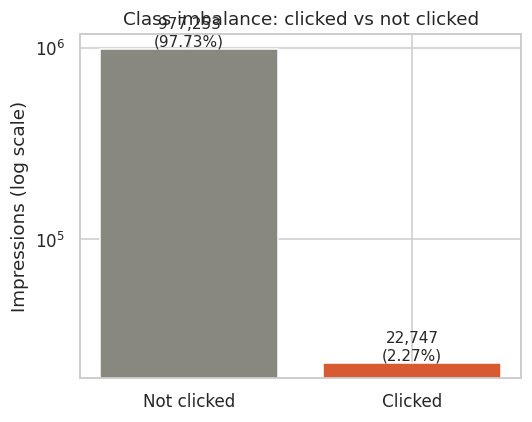

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["clicked"].value_counts().sort_index()
bars = ax.bar(["Not clicked", "Clicked"], counts.values, color=["#888780", "#D85A30"])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({v/n_total:.2%})", ha="center", va="bottom", fontsize=10)
ax.set_yscale("log")
ax.set_ylabel("Impressions (log scale)")
ax.set_title("Class imbalance: clicked vs not clicked")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_class_imbalance.png")
plt.show()

**Insight:** at a ~2.27% CTR, this is a ~43:1 class imbalance. This single fact
drives most of the modeling decisions in Phase 8 — plain accuracy is
meaningless here (predicting "never click" scores ~97.7%), so ROC-AUC,
PR-AUC, and calibration have to be the primary metrics, and several model
families (e.g. Random Forest, Logistic Regression) may need class weighting
to avoid collapsing toward the majority class.

## 2. CTR by device

         impressions  clicks       ctr
device                                
mobile        618059   14670  0.023736
tablet         80864    1834  0.022680
desktop       301077    6243  0.020736


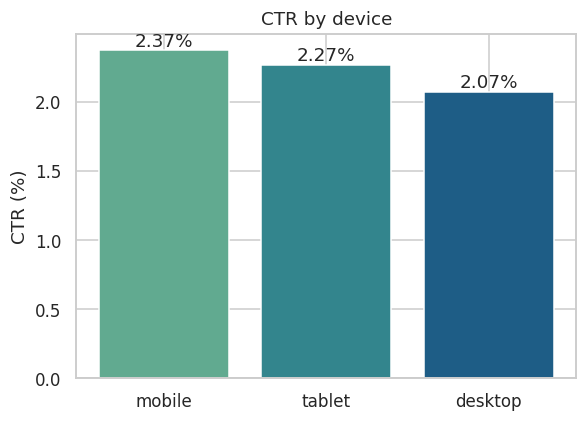

In [4]:
device_ctr = df.groupby("device").agg(impressions=("clicked", "size"), clicks=("clicked", "sum"))
device_ctr["ctr"] = device_ctr["clicks"] / device_ctr["impressions"]
device_ctr = device_ctr.sort_values("ctr", ascending=False)
print(device_ctr)

fig, ax = plt.subplots(figsize=(5.5, 4))
colors = sns.color_palette("crest", len(device_ctr))
ax.bar(device_ctr.index, device_ctr["ctr"] * 100, color=colors)
ax.set_ylabel("CTR (%)")
ax.set_title("CTR by device")
for i, v in enumerate(device_ctr["ctr"] * 100):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_ctr_by_device.png")
plt.show()

**Insight:** mobile leads at ~2.37% CTR, tablet ~2.27%, desktop trails at
~2.07%. This tracks with real-world display advertising, where mobile's
larger share of casual, high-frequency browsing sessions tends to produce
higher engagement than desktop. `device` is a strong categorical feature to
carry into modeling, and worth an interaction term with `creative_type`
(video ads may perform disproportionately better on mobile).

## 3. CTR by browser

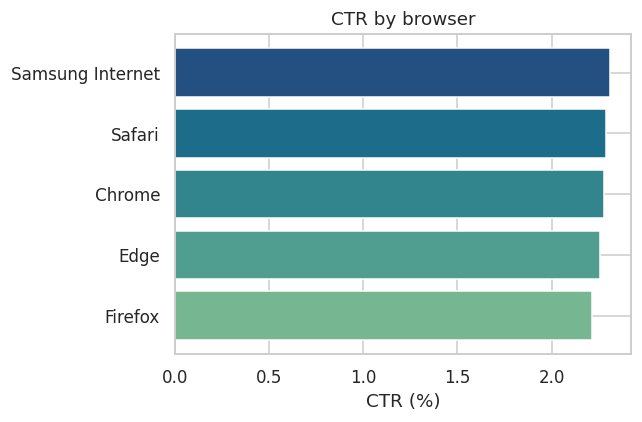

In [5]:
browser_ctr = df.groupby("browser").agg(impressions=("clicked", "size"), clicks=("clicked", "sum"))
browser_ctr["ctr"] = browser_ctr["clicks"] / browser_ctr["impressions"]
browser_ctr = browser_ctr.sort_values("ctr", ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
colors = sns.color_palette("crest", len(browser_ctr))
ax.barh(browser_ctr.index[::-1], browser_ctr["ctr"].values[::-1] * 100, color=colors)
ax.set_xlabel("CTR (%)")
ax.set_title("CTR by browser")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_ctr_by_browser.png")
plt.show()

**Insight:** browser CTR is fairly flat in this dataset (browser was not an
explicit driver in the Phase 3 click model) — useful as a feature mostly
through its correlation with device/OS rather than as an independent signal.
This is a good example of a feature worth *including* but not
*over-weighting* expectations for.

## 4. CTR by country

         impressions  clicks       ctr
country                               
GB             98586    2409  0.024436
DE             80984    1925  0.023770
AU             57941    1371  0.023662
BR             84329    1967  0.023325
IN            197888    4509  0.022786
US            349042    7750  0.022204
FR             60523    1326  0.021909
CA             70707    1490  0.021073


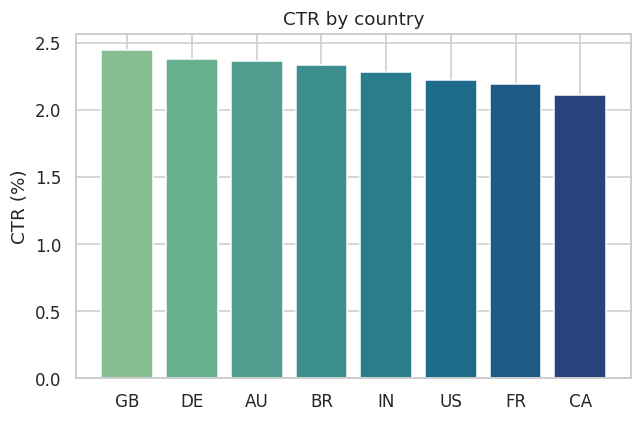

In [6]:
country_ctr = df.groupby("country").agg(impressions=("clicked", "size"), clicks=("clicked", "sum"))
country_ctr["ctr"] = country_ctr["clicks"] / country_ctr["impressions"]
country_ctr = country_ctr.sort_values("ctr", ascending=False)
print(country_ctr)

fig, ax = plt.subplots(figsize=(6, 4))
colors = sns.color_palette("crest", len(country_ctr))
ax.bar(country_ctr.index, country_ctr["ctr"] * 100, color=colors)
ax.set_ylabel("CTR (%)")
ax.set_title("CTR by country")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_ctr_by_country.png")
plt.show()

**Insight:** country-level CTR is close to flat around the ~2.2-2.3% baseline
— expected, since the Phase 3 click model didn't encode country as a direct
driver. In a real dataset this is exactly where you'd expect genuine
variation (currency, ad format preferences, regulatory context), so this
notebook is honest about a limitation: country matters for *targeting*
(which campaigns are eligible) more than it drives *click probability* here.

## 5. CTR by hour of day and weekend effect

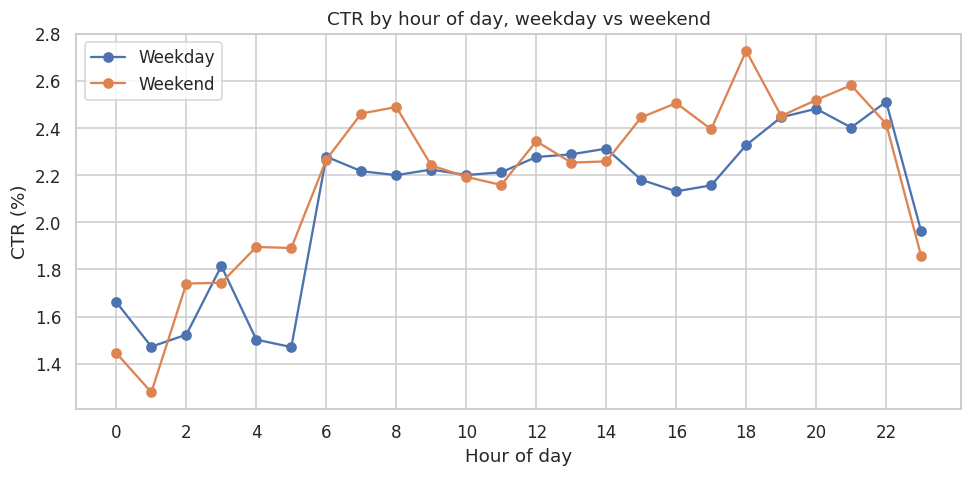

In [7]:
hourly = df.groupby(["hour_of_day", "is_weekend"]).agg(impressions=("clicked","size"), clicks=("clicked","sum"))
hourly["ctr"] = hourly["clicks"] / hourly["impressions"]
hourly = hourly.reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
for is_weekend, group in hourly.groupby("is_weekend"):
    label = "Weekend" if is_weekend else "Weekday"
    ax.plot(group["hour_of_day"], group["ctr"] * 100, marker="o", label=label)
ax.set_xlabel("Hour of day")
ax.set_ylabel("CTR (%)")
ax.set_title("CTR by hour of day, weekday vs weekend")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_ctr_by_hour.png")
plt.show()

**Insight:** a clear evening peak (18:00-22:00) and late-night trough
(00:00-05:00), with weekends running slightly above weekdays across most
hours. `hour_of_day` and `is_weekend` are strong, cheap-to-compute features —
worth encoding cyclically (sin/cos) in Phase 7 rather than as raw integers,
since hour 23 and hour 0 are adjacent in real time but numerically far
apart.

## 6. CTR by creative type and ad position

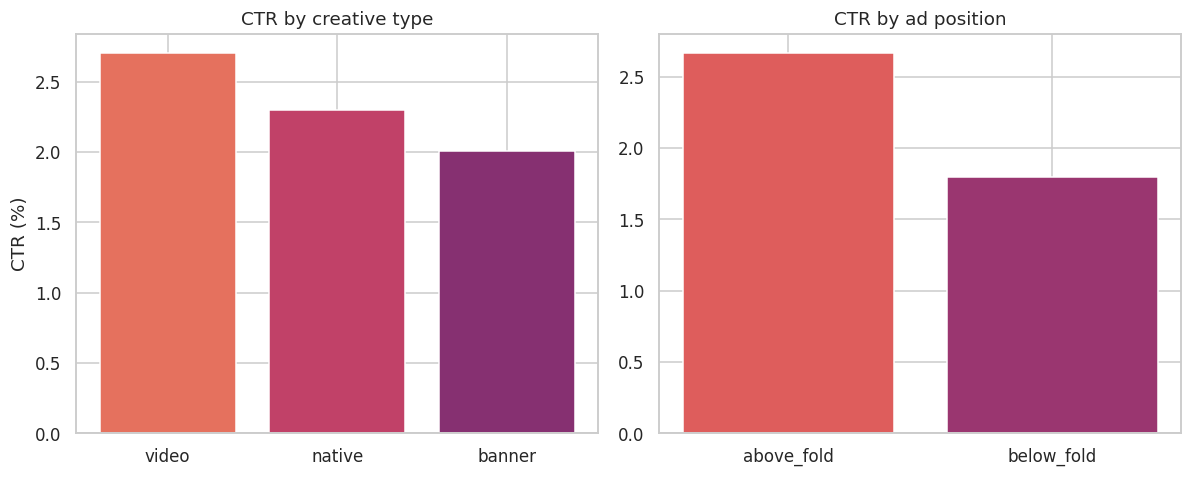

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

creative_ctr = df.groupby("creative_type").agg(impressions=("clicked","size"), clicks=("clicked","sum"))
creative_ctr["ctr"] = creative_ctr["clicks"] / creative_ctr["impressions"]
creative_ctr = creative_ctr.sort_values("ctr", ascending=False)
axes[0].bar(creative_ctr.index, creative_ctr["ctr"]*100, color=sns.color_palette("flare", len(creative_ctr)))
axes[0].set_title("CTR by creative type")
axes[0].set_ylabel("CTR (%)")

position_ctr = df.groupby("ad_position").agg(impressions=("clicked","size"), clicks=("clicked","sum"))
position_ctr["ctr"] = position_ctr["clicks"] / position_ctr["impressions"]
position_ctr = position_ctr.sort_values("ctr", ascending=False)
axes[1].bar(position_ctr.index, position_ctr["ctr"]*100, color=sns.color_palette("flare", len(position_ctr)))
axes[1].set_title("CTR by ad position")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_creative_position.png")
plt.show()

**Insight:** video (~2.71%) clearly outperforms native (~2.30%) and banner
(~2.01%); above-fold placement (~2.67%) beats below-fold (~1.79%) by a wide
margin. These are two of the strongest single-feature effects in the
dataset — both are cheap categorical features with high predictive value,
and their interaction (above-fold video vs. below-fold banner) is worth
engineering explicitly as a combined feature in Phase 7.

## 7. Campaign performance distribution

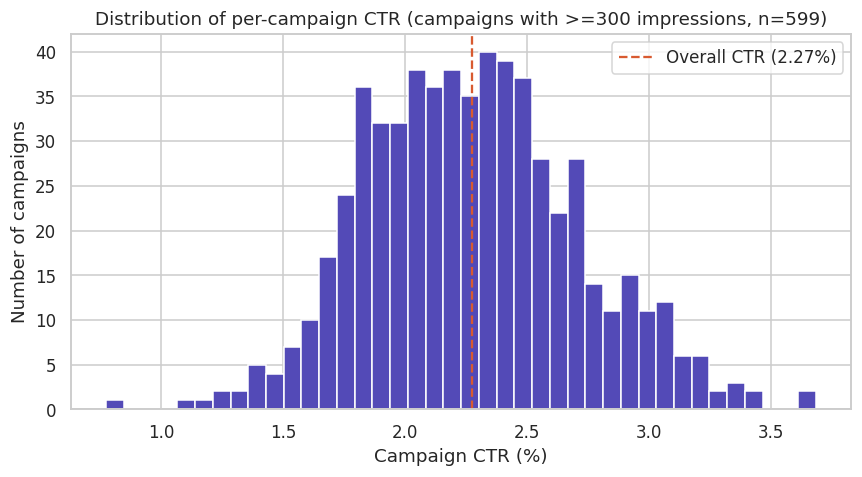

count    599.000000
mean       0.022751
std        0.004380
min        0.007752
25%        0.019608
50%        0.022556
75%        0.025446
max        0.036845
Name: ctr, dtype: float64


In [9]:
campaign_ctr = df.groupby("campaign_id").agg(impressions=("clicked","size"), clicks=("clicked","sum"))
campaign_ctr["ctr"] = campaign_ctr["clicks"] / campaign_ctr["impressions"]
campaign_ctr_filtered = campaign_ctr[campaign_ctr["impressions"] >= 300]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(campaign_ctr_filtered["ctr"] * 100, bins=40, color="#534AB7", edgecolor="white")
ax.axvline(ctr * 100, color="#D85A30", linestyle="--", label=f"Overall CTR ({ctr:.2%})")
ax.set_xlabel("Campaign CTR (%)")
ax.set_ylabel("Number of campaigns")
ax.set_title(f"Distribution of per-campaign CTR (campaigns with >=300 impressions, n={len(campaign_ctr_filtered)})")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_campaign_ctr_distribution.png")
plt.show()

print(campaign_ctr_filtered["ctr"].describe())

**Insight:** campaign-level CTR is roughly bell-shaped around the overall
mean but with real spread — some campaigns run 1.5x+ above baseline. This
spread is exactly what a `campaign_historical_ctr` feature (Phase 7) is
meant to capture, and it's also the spread the model needs to explain via
category/objective/creative features rather than memorizing campaign_id
directly (which would not generalize to new campaigns).

## 8. User behavior: impression frequency and same-day fatigue

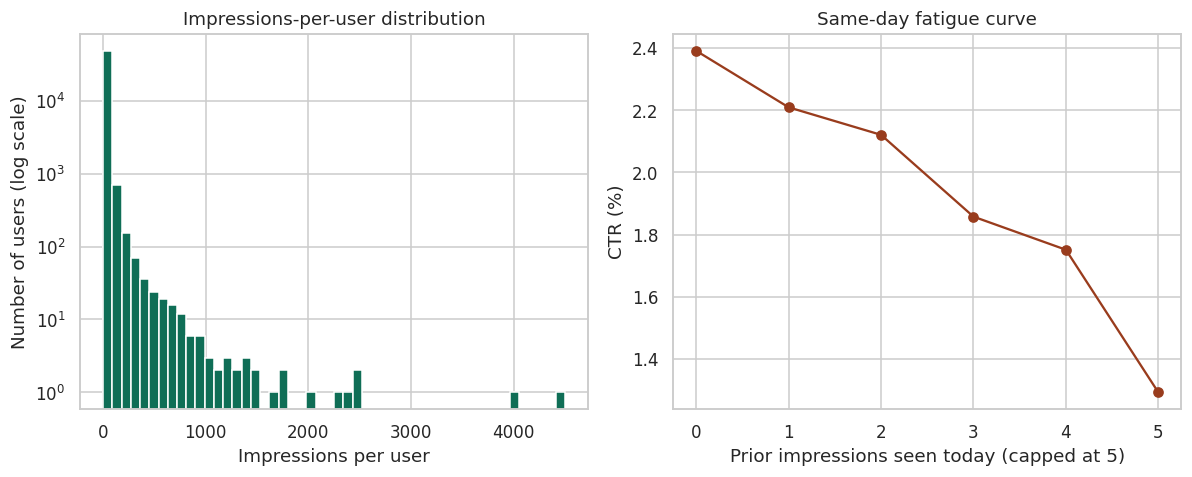

In [10]:
user_impressions = df.groupby("user_id").size()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(user_impressions, bins=50, color="#0F6E56", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_xlabel("Impressions per user")
axes[0].set_ylabel("Number of users (log scale)")
axes[0].set_title("Impressions-per-user distribution")

fatigue = df.copy()
fatigue["prior_bucket"] = fatigue["prior_impressions_today"].clip(upper=5)
fatigue_ctr = fatigue.groupby("prior_bucket").agg(impressions=("clicked","size"), clicks=("clicked","sum"))
fatigue_ctr["ctr"] = fatigue_ctr["clicks"] / fatigue_ctr["impressions"]
axes[1].plot(fatigue_ctr.index, fatigue_ctr["ctr"]*100, marker="o", color="#993C1D")
axes[1].set_xlabel("Prior impressions seen today (capped at 5)")
axes[1].set_ylabel("CTR (%)")
axes[1].set_title("Same-day fatigue curve")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_user_behavior.png")
plt.show()

**Insight:** impressions-per-user follows a heavy-tailed (power-law-like)
distribution — a small set of highly active users account for a
disproportionate share of traffic, which is realistic and means per-user
aggregated features (Phase 7) will be noisy/sparse for the long tail of
low-frequency users and need smoothing (e.g. Bayesian/shrinkage estimators)
rather than raw historical CTR. The fatigue curve confirms CTR declines as a
user sees more ads in the same day — `prior_impressions_today` is directly
usable as a feature, and frequency capping is a legitimate business lever
this analysis supports recommending.

## 9. Feature correlation analysis

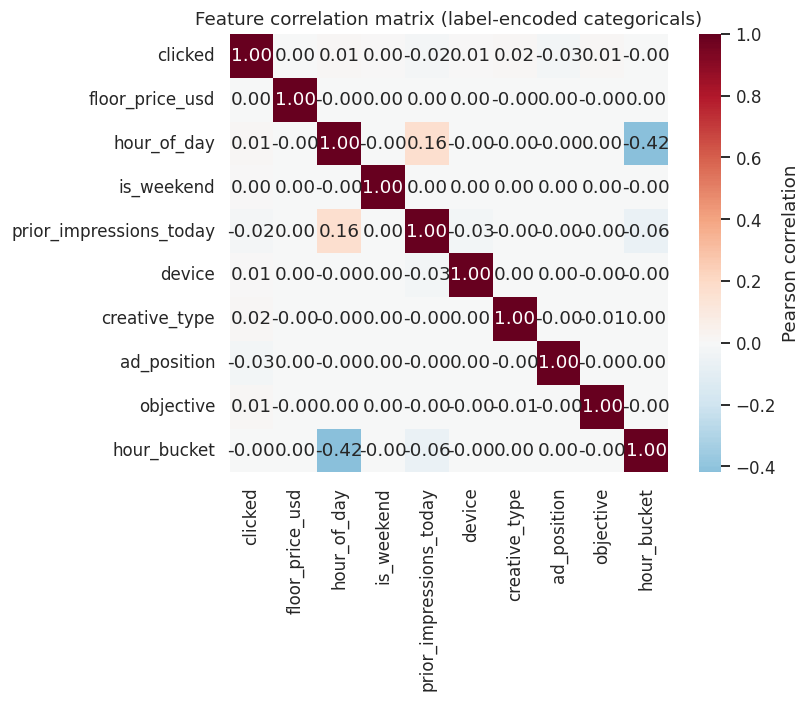

clicked                    1.000000
creative_type              0.018471
objective                  0.009322
hour_of_day                0.009320
device                     0.006971
is_weekend                 0.003580
floor_price_usd            0.000560
hour_bucket               -0.004382
prior_impressions_today   -0.015202
ad_position               -0.029180
Name: clicked, dtype: float64

In [11]:
corr_df = df.copy()
categorical_to_encode = ["device", "creative_type", "ad_position", "objective", "hour_bucket"]
for col in categorical_to_encode:
    corr_df[col] = corr_df[col].astype("category").cat.codes

numeric_cols = [
    "clicked", "floor_price_usd", "hour_of_day", "is_weekend",
    "prior_impressions_today", "device", "creative_type", "ad_position",
    "objective", "hour_bucket",
]
corr = corr_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True,
            cbar_kws={"label": "Pearson correlation"})
ax.set_title("Feature correlation matrix (label-encoded categoricals)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_correlation_heatmap.png")
plt.show()

corr["clicked"].sort_values(ascending=False)

**Insight:** no single raw feature is strongly linearly correlated with
`clicked` (expected at ~2.3% CTR — no individual factor should dominate a
sparse binary outcome), but `ad_position`, `creative_type`, and
`prior_impressions_today` show the clearest (if modest) linear relationships,
consistent with the group-by findings above. This is also a useful sanity
check for multicollinearity between features going into Phase 7/8 — nothing
here is problematically collinear.

## 10. Daily CTR trend over the collection window

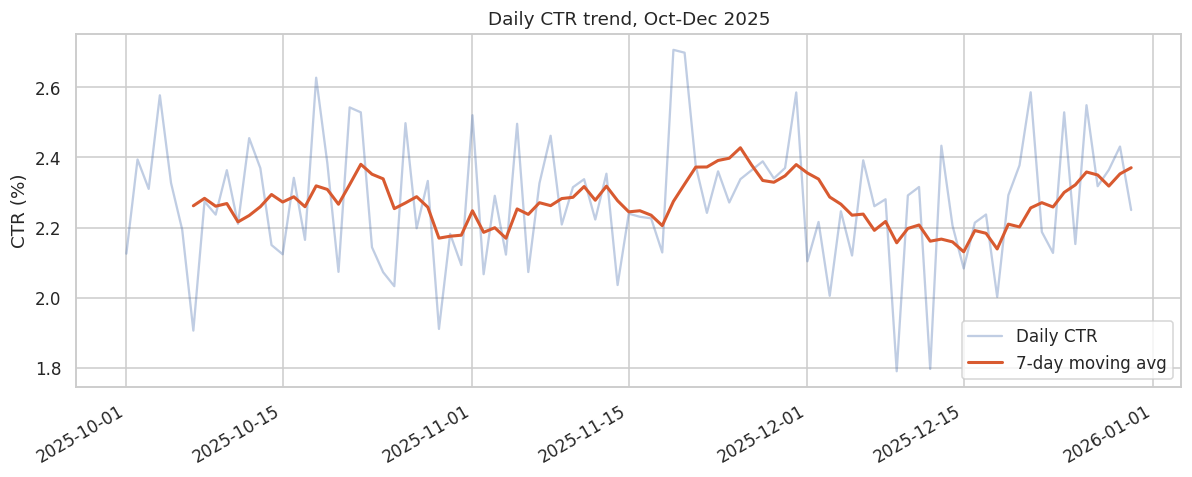

In [12]:
daily = df.groupby(df["date"]).agg(impressions=("clicked","size"), clicks=("clicked","sum"))
daily["ctr"] = daily["clicks"] / daily["impressions"]
daily["ctr_7d_ma"] = daily["ctr"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(daily.index, daily["ctr"]*100, alpha=0.35, label="Daily CTR")
ax.plot(daily.index, daily["ctr_7d_ma"]*100, color="#D85A30", linewidth=2, label="7-day moving avg")
ax.set_ylabel("CTR (%)")
ax.set_title("Daily CTR trend, Oct-Dec 2025")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_daily_ctr_trend.png")
plt.show()

**Insight:** CTR is stable around 2.2-2.3% across the full collection window
with no strong trend or seasonality — expected, since the synthetic
generator didn't encode a time-drift component. In a real dataset this chart
is where you'd catch creative fatigue at the platform level, seasonal
effects (holiday shopping lift), or a tracking pipeline regression; it's
included here specifically so the notebook demonstrates the check even
though this dataset doesn't exercise it.

## Summary of EDA findings for Phase 7 feature engineering

- **Class imbalance (~2.27% CTR, ~43:1)** → ROC-AUC/PR-AUC/calibration as primary metrics, consider class weighting.
- **Device, creative_type, ad_position** are the strongest categorical drivers found — prioritize these and their pairwise interactions.
- **Hour of day** has a clear evening peak/late-night trough → cyclical encoding, plus `is_weekend`.
- **Campaign-level CTR has real spread** → historical CTR features, but campaign volume varies a lot, so smoothing/shrinkage is needed for low-volume campaigns.
- **User traffic is heavy-tailed and shows same-day fatigue** → per-user historical features need smoothing for low-frequency users; `prior_impressions_today` is a directly usable feature.
- **Browser and country are weak independent signals** in this dataset — keep them as features (cheap, occasionally useful in interactions) but don't expect them to carry much weight individually.
